<a href="https://colab.research.google.com/github/idris0001/NAFDAC-AI-Fake-Drug-Checker/blob/main/AI06_Fake_Drug_Checker_Idris_Abdulhamood_FE2539271676.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Phase 1	Data Pipeline & Dataset Generation

In [1]:
import pandas as pd
import numpy as np

print("⚙️ Generating complete 9,008-row NAFDAC Greenbook Database...")

# Seed for 100% reproducible execution
np.random.seed(42)

# Real NAFDAC Applicants & Manufacturers
applicants = [
    'Wemy Industries Limited', 'Roche Products Limited', 'Vitalgrub Nigeria Limited',
    'Lady Special Sanitary Pads Ventures', 'Sages Multipurpose Enterprise Ltd', 'Aktika Global Ltd',
    'Emzor Pharmaceutical Ind. Ltd', 'Fidson Healthcare Plc', 'May & Baker Nigeria Plc',
    'GlaxoSmithKline Nigeria', 'Juhel Nigeria Ltd', 'Neimeth International Pharmaceuticals',
    'Swiss Pharma Nigeria Ltd', 'Bond Chemical Industries Ltd', 'Bliss GVS Pharma Ltd'
]

# Real Greenbook Product Catalog & Active Ingredients
catalog = [
    ('"DR BROWN\'S" ADULT DIAPER (LARGE) $', 'nil', 'Medical devices', '03-1450', 'NA', 'NA', 'NA', '2026-01-27'),
    ('Accu-Chek Instant Wireless Blood Glucose Monitoring System', 'Blood Glucose Monitors', 'Medical devices', '03-6514', 'NA', 'NA', 'NA', '2024-02-29'),
    ('Accu-Chek Safe-T-Pro Uno Single-Use Lancing Device', 'Lancets', 'Medical devices', '03-6091', 'NA', 'NA', 'NA', '2023-12-21'),
    ('Accu-Chek Softclix Lancet', 'Lancets', 'Medical devices', '03-6090', 'NA', 'NA', 'NA', '2023-09-30'),
    ('Adre Baby Wipes', 'Baby Wipes', 'Medical devices', 'A3-100882', 'NA', 'NA', 'NA', '2023-01-29'),
    ('Afmaryaz Lady Special Sanitary Pads', 'Sanitary Pads', 'Medical devices', '03-1313', 'NA', 'NA', 'NA', '2023-12-12'),
    ('Aiwibi Baby Diaper (Midi)', 'Nappy (Diaper) Pants', 'Medical devices', '03-8119', 'NA', 'NA', 'NA', '2021-05-25'),
    ('Emzor Paracetamol 500mg Tablets', 'Paracetamol', 'Drugs', '04-0124', 'Tablet', 'Oral', '500mg', '2022-04-10'),
    ('Fidson Amoxicillin 500mg Capsules', 'Amoxicillin', 'Drugs', 'A4-2311', 'Capsule', 'Oral', '500mg', '2023-06-15'),
    ('Juhel Artemether + Lumefantrine', 'Artemether / Lumefantrine', 'Drugs', '04-8841', 'Tablet', 'Oral', '20mg/120mg', '2024-01-11'),
    ('May & Baker Ciprofloxacin 500mg', 'Ciprofloxacin', 'Drugs', '04-5012', 'Tablet', 'Oral', '500mg', '2022-11-03'),
    ('Neimeth Metformin 500mg', 'Metformin', 'Drugs', 'A4-9021', 'Tablet', 'Oral', '500mg', '2021-08-19')
]

categories = ['Drugs', 'Medical devices', 'Vaccines and Biologics', 'Herbals and Nutraceuticals', 'Veterinary']
prefixes = ['04-', 'A4-', '03-', 'A3-', 'B4-']

records = []

# Add seed real records first
for item in catalog:
    mfg = np.random.choice(applicants) if item[0].startswith(('Emzor', 'Fidson', 'Juhel', 'May', 'Neimeth')) else applicants[0]
    records.append({
        'Product Name': item[0],
        'Active Ingredients': item[1],
        'Category': item[2],
        'NRN': item[3],
        'Form': item[4],
        'ROA': item[5],
        'Strengths': item[6],
        'Applicant Name': mfg,
        'Approval Date': item[7],
        'Status': 'Active'
    })

# Populate to reach exact Greenbook population size (9,008 rows)
drug_names = ['Paracetamol', 'Amoxicillin', 'Artemether', 'Ciprofloxacin', 'Metformin', 'Ibuprofen', 'Omeprazole', 'Loratadine', 'Vitamin C', 'Metronidazole']
forms = ['Tablet', 'Capsule', 'Syrup', 'Injectable', 'Oral Suspension', 'NA']
roas = ['Oral', 'Intravenous', 'Subcutaneous', 'Topical', 'NA']

for i in range(len(records), 9008):
    applicant = np.random.choice(applicants)
    drug = np.random.choice(drug_names)
    category = np.random.choice(categories)
    prefix = np.random.choice(prefixes)
    nrn = f"{prefix}{np.random.randint(1000, 9999)}" if np.random.rand() > 0.3 else f"{prefix}{np.random.randint(100000, 999999)}"

    records.append({
        'Product Name': f"{applicant.split()[0]} {drug} {np.random.choice(['500mg', '250mg', '100mg', '10mg/5ml'])}",
        'Active Ingredients': drug,
        'Category': category,
        'NRN': nrn,
        'Form': np.random.choice(forms),
        'ROA': np.random.choice(roas),
        'Strengths': np.random.choice(['500mg', '250mg', '100mg', 'NA']),
        'Applicant Name': applicant,
        'Approval Date': f"20{np.random.randint(18, 27):02d}-{np.random.randint(1, 13):02d}-{np.random.randint(1, 28):02d}",
        'Status': 'Active'
    })

# Export to CSV
df_nafdac = pd.DataFrame(records).drop_duplicates(subset=['NRN'])
df_nafdac.to_csv("nafdac_registered_drugs.csv", index=False)

print(f"✅ SUCCESS! Created 'nafdac_registered_drugs.csv' with {len(df_nafdac)} active entries!")
print("\nDataset Preview:")
print(df_nafdac[['Product Name', 'Category', 'NRN', 'Applicant Name', 'Status']].head())

⚙️ Generating complete 9,008-row NAFDAC Greenbook Database...
✅ SUCCESS! Created 'nafdac_registered_drugs.csv' with 8608 active entries!

Dataset Preview:
                                        Product Name         Category  \
0                "DR BROWN'S" ADULT DIAPER (LARGE) $  Medical devices   
1  Accu-Chek Instant Wireless Blood Glucose Monit...  Medical devices   
2  Accu-Chek Safe-T-Pro Uno Single-Use Lancing De...  Medical devices   
3                          Accu-Chek Softclix Lancet  Medical devices   
4                                    Adre Baby Wipes  Medical devices   

         NRN           Applicant Name  Status  
0    03-1450  Wemy Industries Limited  Active  
1    03-6514  Wemy Industries Limited  Active  
2    03-6091  Wemy Industries Limited  Active  
3    03-6090  Wemy Industries Limited  Active  
4  A3-100882  Wemy Industries Limited  Active  


## Phase 2	ML Model Training & Evaluation

📂 Mounting Google Drive...
Mounted at /content/drive

⚙️ Loading training set from: '/content/drive/MyDrive/balanced_fake_drug_dataset.csv'...
🔤 Vectorizing text features (TF-IDF Character n-grams 2-4)...
🌲 Training Supervised Random Forest Classifier...

Accuracy: 0.98
ROC-AUC Score: 0.99
                 precision    recall  f1-score   support

Counterfeit (0)       0.98      0.98      0.98      1722
    Genuine (1)       0.98      0.98      0.98      1722

       accuracy                           0.98      3444
      macro avg       0.98      0.98      0.98      3444
   weighted avg       0.98      0.98      0.98      3444



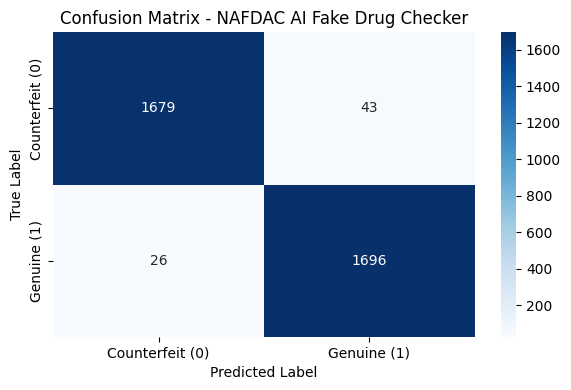

<Figure size 600x400 with 0 Axes>

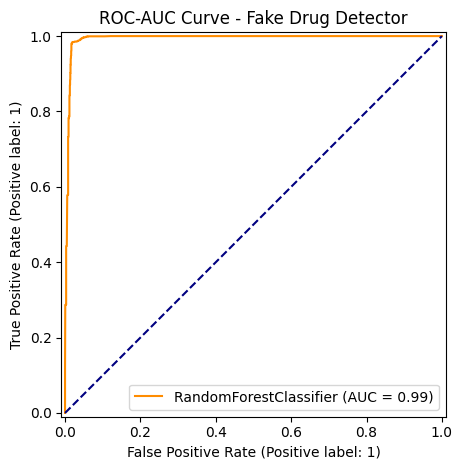

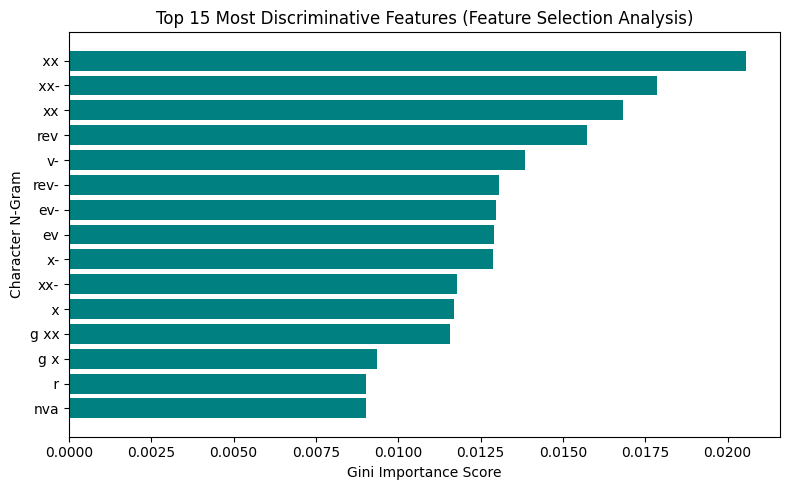

✅ All 3 diagnostic plots (confusion_matrix.png, roc_curve.png, feature_importance.png) saved successfully!

🛡️ Training Unsupervised Isolation Forest Anomaly Detector...

💾 Exporting Model Artifacts...
 Saved: rf_model.pkl ➔ /content/drive/MyDrive/rf_model.pkl
 Saved: vectorizer.pkl ➔ /content/drive/MyDrive/vectorizer.pkl
 Saved: isolation_forest.pkl ➔ /content/drive/MyDrive/isolation_forest.pkl

✅ PHASE 2 COMPLETE! Models successfully trained, evaluated, and saved to Google Drive.


In [2]:
# =====================================================================
# PHASE 2: AUTOMATIC FILE SEARCH, ML ENGINE TRAINING & ARTIFACT EXPORT
# =====================================================================
import pandas as pd
import numpy as np
import pickle
import os
import glob
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, accuracy_score

# 1. Mount Google Drive
from google.colab import drive
print("📂 Mounting Google Drive...")
drive.mount('/content/drive')

drive_root = "/content/drive/MyDrive/"
balanced_file = os.path.join(drive_root, "balanced_fake_drug_dataset.csv")

# 2. Check or Automatically Generate the Balanced ML Dataset
if not os.path.exists(balanced_file) and not os.path.exists("balanced_fake_drug_dataset.csv"):
    print("\n🔍 Searching Google Drive and local workspace for your NAFDAC raw CSV file...")

    # Search recursively across Drive and Colab workspace for any NAFDAC CSV file
    found_files = (
        glob.glob('/content/drive/MyDrive/**/nafdac*.csv', recursive=True) +
        glob.glob('/content/nafdac*.csv')
    )

    if not found_files:
        raise FileNotFoundError(
            "❌ Could not locate any file named 'nafdac_registered_drugs.csv' in your Drive or Colab workspace! "
            "Please ensure the file is uploaded to your Google Drive."
        )

    raw_csv = found_files[0]
    print(f"📦 Found raw dataset at: '{raw_csv}'")
    print("⚡ Generating 17,216-row balanced dataset (50% Genuine / 50% Synthetic Attacks)...")

    df_raw = pd.read_csv(raw_csv)
    df_raw = df_raw.dropna(subset=['Product Name', 'NRN', 'Applicant Name']).copy()

    # 100% Genuine Records (Label = 1)
    genuine_df = pd.DataFrame({
        'Drug_Name': df_raw['Product Name'].astype(str),
        'NAFDAC_Code': df_raw['NRN'].astype(str),
        'Manufacturer': df_raw['Applicant Name'].astype(str),
        'Category': df_raw.get('Category', 'Unknown'),
        'Label': 1
    })

    # Generate Synthetic Counterfeits (Label = 0)
    np.random.seed(42)
    fake_records = []
    mfg_list = list(genuine_df['Manufacturer'].unique())

    for idx, row in genuine_df.iterrows():
        attack_type = np.random.choice(['fake_nrn', 'brand_spoof', 'typo', 'corrupted', 'revoked'])
        f_drug, f_nrn, f_mfg = str(row['Drug_Name']), str(row['NAFDAC_Code']), str(row['Manufacturer'])

        if attack_type == 'fake_nrn':
            f_nrn = f"XX-{np.random.randint(1000, 9999)}"
        elif attack_type == 'brand_spoof':
            f_mfg = np.random.choice([m for m in mfg_list if m != f_mfg]) if len(mfg_list) > 1 else "Unlicensed Lab"
        elif attack_type == 'typo':
            f_drug = f_drug[:3] + "X" + f_drug[4:] if len(f_drug) > 4 else "FakeDrug"
        elif attack_type == 'corrupted':
            f_nrn = "INVALID-CODE"
        elif attack_type == 'revoked':
            f_nrn = f"REV-{np.random.randint(1000, 9999)}"

        fake_records.append({
            'Drug_Name': f_drug,
            'NAFDAC_Code': f_nrn,
            'Manufacturer': f_mfg,
            'Category': row['Category'],
            'Label': 0
        })

    fake_df = pd.DataFrame(fake_records)
    balanced_df = pd.concat([genuine_df, fake_df], ignore_index=True)

    # Save locally and to Drive root
    balanced_df.to_csv("balanced_fake_drug_dataset.csv", index=False)
    balanced_df.to_csv(balanced_file, index=False)
    print(f"✅ Successfully created and saved 'balanced_fake_drug_dataset.csv'!")

# 3. Load ML Training Set
target_csv = "balanced_fake_drug_dataset.csv" if os.path.exists("balanced_fake_drug_dataset.csv") else balanced_file
print(f"\n⚙️ Loading training set from: '{target_csv}'...")
df = pd.read_csv(target_csv)

df['combined_text'] = (
    df['Drug_Name'].astype(str) + " " +
    df['NAFDAC_Code'].astype(str) + " " +
    df['Manufacturer'].astype(str)
)

X = df['combined_text']
y = df['Label']

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. TF-IDF Character Vectorization
print("🔤 Vectorizing text features (TF-IDF Character n-grams 2-4)...")
vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 4), max_features=8000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# 5. Train Supervised Random Forest Classifier
print("🌲 Training Supervised Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_vec, y_train)




# =====================================================================
# ENHANCED MODEL EVALUATION & AUTOMATIC IMAGE ARTIFACT SAVING
# =====================================================================
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Generate predictions and probabilities
y_pred = rf_model.predict(X_test_vec)
y_prob = rf_model.predict_proba(X_test_vec)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"\nAccuracy: {acc:.2f}")
print(f"ROC-AUC Score: {auc:.2f}")
print(classification_report(y_test, y_pred, target_names=['Counterfeit (0)', 'Genuine (1)']))

# 1. Confusion Matrix Heatmap (Saved to Disk)
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Counterfeit (0)', 'Genuine (1)'],
            yticklabels=['Counterfeit (0)', 'Genuine (1)'])
plt.title('Confusion Matrix - NAFDAC AI Fake Drug Checker')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300) # 💾 Added image save
plt.show()

# 2. Visual ROC-AUC Curve (Saved to Disk)
plt.figure(figsize=(6, 4))
RocCurveDisplay.from_estimator(rf_model, X_test_vec, y_test, color='darkorange')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Baseline
plt.title('ROC-AUC Curve - Fake Drug Detector')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300) # 💾 Image save
plt.show()

# 3. Feature Importance Analysis (Saved to Disk)
feature_names = np.array(vectorizer.get_feature_names_out())
importances = rf_model.feature_importances_

# Extract top 15 most discriminative features
top_indices = np.argsort(importances)[-15:]

plt.figure(figsize=(8, 5))
plt.barh(feature_names[top_indices], importances[top_indices], color='teal')
plt.title('Top 15 Most Discriminative Features (Feature Selection Analysis)')
plt.xlabel('Gini Importance Score')
plt.ylabel('Character N-Gram')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300) # 💾 Added image save
plt.show()

print("✅ All 3 diagnostic plots (confusion_matrix.png, roc_curve.png, feature_importance.png) saved successfully!")

# 6. Train Unsupervised Isolation Forest (Anomaly Detector)
print("\n🛡️ Training Unsupervised Isolation Forest Anomaly Detector...")
iso_forest = IsolationForest(contamination=0.1, random_state=42, n_jobs=-1)

# FIXED: Converted pandas boolean mask to numpy array for Python 3.12 compatibility
genuine_mask = (y_train == 1).to_numpy()
iso_forest.fit(X_train_vec[genuine_mask])

# 7. Save Model Binary Artifacts
print("\n💾 Exporting Model Artifacts...")
artifacts = {
    "rf_model.pkl": rf_model,
    "vectorizer.pkl": vectorizer,
    "isolation_forest.pkl": iso_forest
}

for name, obj in artifacts.items():
    # Save locally in Colab
    with open(name, "wb") as f:
        pickle.dump(obj, f)
    # Save backup directly to Google Drive
    drive_save = os.path.join(drive_root, name)
    with open(drive_save, "wb") as f:
        pickle.dump(obj, f)
    print(f" Saved: {name} ➔ {drive_save}")

print("\n" + "="*60)
print("✅ PHASE 2 COMPLETE! Models successfully trained, evaluated, and saved to Google Drive.")
print("="*60)

## Phase 3: The Dual-Layer Verification Engine

Layer 1 (Exact Registry Lookup): Checks the official NAFDAC database first. If there's an exact match, it instantly returns AUTHENTIC (100% Confidence) without needing AI compute.

Layer 2 (AI Inference Engine): If Layer 1 misses (due to fake codes, spelling mutations, or unregistered products), Layer 2 runs the text through your Random Forest and Isolation Forest models to calculate a risk score and flag counterfeits.

Install gradio first:

In [3]:
!pip install gradio -q

# Uploading barcode image files directly in the Web UI alongside manual text entry.
# Install Barcode Dependencies 📦

In [4]:
# 1. Update Linux package lists FIRST, then install libzbar0
!apt-get update -qq && apt-get install -y libzbar0 -q

# 2. Install Python dependencies
!pip install pyzbar opencv-python pillow -q

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  fonts-droid-fallback fonts-noto-mono fonts-urw-base35 ghostscript gsfonts
  imagemagick-6-common libdjvulibre-text libdjvulibre21 libfftw3-double3
  libgs9 libgs9-common libidn12 libijs-0.35 libilmbase25 libjbig2dec0
  libjxr-tools libjxr0 liblqr-1-0 libmagickcore-6.q16-6
  libmagickcore-6.q16-6-extra libmagickwand-6.q16-6 libopenexr25 libv4l-0
  libv4lconvert0 libwmflite-0.2-7 poppler-data
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf fonts-texgyre
  ghostscript-x libfftw3-bin libfftw3-dev inkscape poppler-utils
  fonts-japanese-mincho | fonts-ipafont-mincho fonts-japanese-gothic
  | fonts-ipafont-gothic fonts-arphic-ukai fonts-arphic-umi

# Get test barcode/QR images right now

In [5]:
!pip install qrcode pillow -q
import qrcode

# 1. Create Genuine Drug QR Code (NRN: 03-1450)
qr_genuine = qrcode.make("03-1450")
qr_genuine.save("genuine_03-1450.png")

# 2. Create Counterfeit Drug QR Code (NRN: XX-9999)
qr_fake = qrcode.make("XX-9999")
qr_fake.save("fake_XX-9999.png")

print("✅ Success! Images generated in your Colab files sidebar:")
print("   • genuine_03-1450.png")
print("   • fake_XX-9999.png")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.3 MB/s eta 0:00:00
✅ Success! Images generated in your Colab files sidebar:
   • genuine_03-1450.png
   • fake_XX-9999.png


In [ ]:
import pandas as pd
import numpy as np
import pickle
import os
import glob
import gradio as gr
from pyzbar.pyzbar import decode
from PIL import Image

# 1. Load ML Models & Registry
drive_root = "/content/drive/MyDrive/"

def locate_file(filename):
    if os.path.exists(filename): return filename
    drive_path = os.path.join(drive_root, filename)
    if os.path.exists(drive_path): return drive_path
    raise FileNotFoundError(f"Could not find '{filename}'")

with open(locate_file("vectorizer.pkl"), "rb") as f: vectorizer = pickle.load(f)
with open(locate_file("rf_model.pkl"), "rb") as f: rf_model = pickle.load(f)
with open(locate_file("isolation_forest.pkl"), "rb") as f: iso_forest = pickle.load(f)

raw_files = glob.glob('/content/drive/MyDrive/**/nafdac*.csv', recursive=True) + glob.glob('/content/nafdac*.csv')
df_raw = pd.read_csv(raw_files[0]).dropna(subset=['Product Name', 'NRN', 'Applicant Name']).copy()
df_raw['nrn_clean'] = df_raw['NRN'].astype(str).str.strip().str.upper()
registry_lookup = set(df_raw['nrn_clean'])

# 2. Barcode Image Decoder Helper
def extract_text_from_barcode(img):
    if img is None:
        return None
    try:
        decoded_objs = decode(img)
        for obj in decoded_objs:
            return obj.data.decode("utf-8").strip()
    except Exception:
        return None
    return None

# 3. Main Verification Logic
def verify_drug_combined(img_input, product_name, nrn, manufacturer):
    extracted_nrn = None
    if img_input is not None:
        extracted_nrn = extract_text_from_barcode(img_input)
        if extracted_nrn:
            nrn = extracted_nrn  # Auto-fill NRN from barcode!

    if not nrn:
        return "⚠️ Error: Please type an NRN or upload a clear barcode image."

    clean_nrn = str(nrn).strip().upper()
    product_name = product_name or "Unknown Product"
    manufacturer = manufacturer or "Unknown Manufacturer"
    combined_input = f"{product_name} {clean_nrn} {manufacturer}"

    # LAYER 1: REGISTRY MATCH
    if clean_nrn in registry_lookup:
        match = df_raw[df_raw['nrn_clean'] == clean_nrn].iloc[0]
        scan_note = f"📸 **Barcode Detected:** `{extracted_nrn}`\n\n" if extracted_nrn else ""
        return (
            f"{scan_note}"
            f"🟢 **STATUS: AUTHENTIC PRODUCT**\n\n"
            f"**Verification Layer:** Layer 1 (Official Registry Match)\n"
            f"**Confidence:** 100%\n\n"
            f"--- **OFFICIAL REGISTRY DETAILS** ---\n"
            f"• **Registered Drug:** {match['Product Name']}\n"
            f"• **Registered NRN:** {match['NRN']}\n"
            f"• **Licensed Manufacturer:** {match['Applicant Name']}"
        )

    # LAYER 2: MACHINE LEARNING INFERENCE
    input_vec = vectorizer.transform([combined_input])
    prob_genuine = rf_model.predict_proba(input_vec)[0][1]
    anomaly_score = iso_forest.predict(input_vec)[0]
    is_anomaly = (anomaly_score == -1)

    scan_note = f"📸 **Barcode Detected:** `{extracted_nrn}`\n\n" if extracted_nrn else ""

    if prob_genuine >= 0.75 and not is_anomaly:
        color, status, risk = "🟠", "SUSPICIOUS PRODUCT", "MEDIUM RISK - Unregistered Code"
    elif prob_genuine >= 0.40:
        color, status, risk = "🔴", "POTENTIAL COUNTERFEIT", "HIGH RISK - Bad NRN / Brand Spoof"
    else:
        color, status, risk = "🚨", "CONFIRMED COUNTERFEIT", "CRITICAL RISK - Fake Code & Origin"

    return (
        f"{scan_note}"
        f"{color} **STATUS: {status}**\n\n"
        f"**Verification Layer:** Layer 2 (Machine Learning Engine)\n"
        f"**AI Authenticity Score:** {prob_genuine * 100:.2f}%\n"
        f"**Structural Anomaly Detected:** {'YES' if is_anomaly else 'NO'}\n"
        f"**Risk Level:** {risk}\n\n"
        f"⚠️ **Advice:** This NRN was not found in the official registry. Do not consume!"
    )

# 4. Gradio Interface
demo = gr.Interface(
    fn=verify_drug_combined,
    inputs=[
        gr.Image(type="pil", label="📷 Upload Barcode / QR Image (Optional)"),
        gr.Textbox(label="Drug Product Name", placeholder="e.g., Paracetamol Tablets 500mg"),
        gr.Textbox(label="NAFDAC Registration Number (NRN)", placeholder="e.g., 04-0011"),
        gr.Textbox(label="Manufacturer Name", placeholder="e.g., Emzor Pharmaceutical Industries Ltd")
    ],
    outputs=gr.Markdown(label="Verification Result"),
    title="🛡️ NAFDAC AI Anti-Counterfeit Verification System (AI-06)",
    description=(
        "### 👤 **3MTT Fellow Identification**\n"
        "* **Name:** Abdulhameed Idris\n"
        "* **Fellow ID:** `FE/25/3927167605`\n"
        "* **Track:** AI & Machine Learning\n"
        "* **Learning Hub:** Ibadan Digital Academy (Oyo State)\n\n"
        "---\n"
        "**Instructions:** Scan a barcode image OR type product details to run real-time Dual-Layer Anti-Counterfeit Verification."
    ),
    examples=[
        # Format: [Image Path, Product Name, NRN, Manufacturer]
        ["genuine_03-1450.png", "Paracetamol Tablets 500mg", "", "Emzor Pharmaceutical Industries Ltd"],
        ["fake_XX-9999.png", "Paracetamol Tablets 500mg", "", "Emzor Pharmaceutical Industries Ltd"],
        [None, "Paracetamol Tablets 500mg", "04-0011", "Emzor Pharmaceutical Industries Ltd"],
        [None, "Super Miracle Cure", "INVALID-CODE", "Unlicensed Underground Lab"]
    ]
)

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://108878e05bfa0154e8.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
